In [14]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import gstools as gs
import pymc as pm
import statsmodels.api as sm
import arviz as az
import pytensor.tensor as pt
import pickle
import pathlib
from scipy.spatial.distance import cdist

In [15]:
agg = pd.read_csv('../data/senate_general_zip_20_22.csv')
agg['ZIP_CODE'] = agg['ZIP_CODE'].astype(str).str.zfill(5)

In [16]:
agg = pd.read_csv('../data/senate_general_zip_20_22.csv')
agg['ZIP_CODE'] = agg['ZIP_CODE'].astype(str).str.zfill(5)
agg["sum_20"] = agg["sum_20"].apply(lambda x: max(0, x))
agg["sum_22"] = agg["sum_22"].apply(lambda x: max(0, x))

agg["delta_log"] = np.log(agg['sum_22'] + 1) - np.log(agg['sum_20'] + 1)

agg["total"] = agg["sum_20"] + agg["sum_22"]
agg = agg[agg["total"] >= 50].copy()
agg = agg[np.logical_and(agg['lng'] > -85, agg['lng'] < -75)].copy()
agg = agg[agg['lat'] > 25].copy()
agg = agg[agg['lat'] < 50].copy()

census = pd.read_csv('../data/census_cleaned.csv')
census["zip_code"] = census["zip_code"].astype(str).str.zfill(5)
agg = agg.merge(census, left_on="ZIP_CODE", right_on="zip_code", how="inner")
agg = agg.drop(columns=["zip_code"])
agg.shape

(5538, 12)

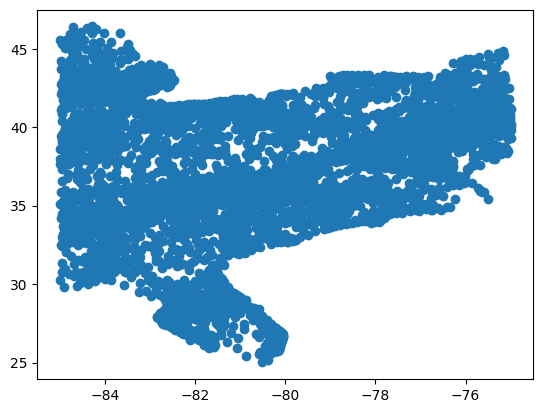

In [17]:
plt.plot(agg['lng'], agg['lat'], 'o', label='data points')

In [18]:
census_covariates = ["population", "median_income"]

X = agg[census_covariates].astype(float)
X = (X - X.mean()) / X.std(ddof=0)
X = sm.add_constant(X)

ols_delta_log = sm.OLS(agg["delta_log"], X).fit()
agg["delta_log_ols_fitted"] = ols_delta_log.fittedvalues
agg["delta_log_resid"] = ols_delta_log.resid
ols_delta_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              delta_log   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     45.07
Date:                Mon, 04 May 2026   Prob (F-statistic):           3.85e-20
Time:                        11:42:09   Log-Likelihood:                -14411.
No. Observations:                5538   AIC:                         2.883e+04
Df Residuals:                    5535   BIC:                         2.885e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.6382      0.044    -82.896      0.000      -3.724      -3.552
population        0.3911      0.044      8.873      0.000       0.305       0.478
median_income     0.1121      0.044      2.544      0.011       0.026       0.199
==============================================================================
Omnibus:                      641.069   Durbin-Watson:                   1.864
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              954.730
Skew:                           0.857   Prob(JB):                    4.82e-208
Kurtosis:                       4.096   Cond. No.                         1.10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
# sample split into 80% train, 20% test
train = agg.sample(frac=0.8, random_state=305)
test = agg.drop(train.index)

In [17]:
gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train["lng"], train["lat"]),
    crs="EPSG:4326"
)

# use a US projection (meters)
gdf = gdf.to_crs("EPSG:5070")  # NAD83 / Conus Albers

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
values = gdf["delta_log_resid"].values

In [18]:
maxlag = 500_000   # 500 km
n_lags = 30

bin_edges = np.linspace(0, maxlag, n_lags + 1)

bin_center, gamma, counts = gs.vario_estimate(
    (coords[:,0], coords[:,1]),
    values,
    bin_edges=bin_edges,
    return_counts=True
)

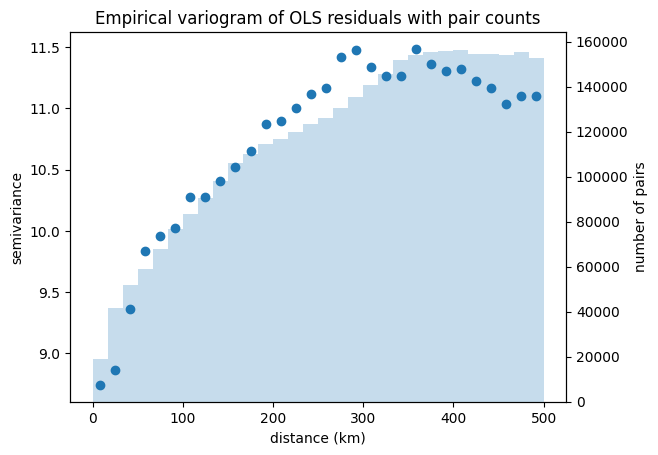

In [19]:
fig, ax1 = plt.subplots()

ax1.scatter(bin_center / 1000, gamma, label="empirical")
ax1.set_xlabel("distance (km)")
ax1.set_ylabel("semivariance")

ax2 = ax1.twinx()
ax2.bar(bin_center / 1000, counts, alpha=0.25, width=(maxlag / n_lags) / 1000)
ax2.set_ylabel("number of pairs")

plt.title("Empirical variogram of OLS residuals with pair counts")
plt.show()

In [20]:
model_resid = gs.Spherical(dim=2)
model_resid.fit_variogram(bin_center, gamma)

print("range:", model_resid.len_scale)
print("sill:", model_resid.var)
print("nugget:", model_resid.nugget)

range: 292196.4761491913
sill: 2.449167011655692
nugget: 8.814748020315237


In [21]:
model = gs.Spherical(
    dim=2,
    var=model_resid.var,
    len_scale=model_resid.len_scale,
    nugget=model_resid.nugget
)

krig = gs.krige.Ordinary(
    model,
    cond_pos=(coords[:,0], coords[:,1]),
    cond_val=values
)

In [ ]:
# compute kriged residual predictions on the held-out set
test_coords = gpd.GeoSeries(
    gpd.points_from_xy(test["lng"], test["lat"])
).set_crs("EPSG:4326").to_crs("EPSG:5070")
test_coords = np.column_stack([test_coords.x, test_coords.y])

test_values = test["delta_log"].values
test_residuals = test["delta_log_resid"].values

results_test = krig(test_coords.T)
test = test.copy()
test["delta_log_resid_kriged"] = results_test[0]
test["delta_log_ols_kriged"] = (
    test["delta_log_ols_fitted"] + test["delta_log_resid_kriged"]
)

In [ ]:
null_pred = train["delta_log"].mean()
ols_pred = test["delta_log_ols_fitted"]
ols_krig_pred = test["delta_log_ols_kriged"]

null_errors = test_values - null_pred
ols_errors = test_values - ols_pred
ols_krig_errors = test_values - ols_krig_pred
resid_krig_errors = test_residuals - test["delta_log_resid_kriged"]

comparison = pd.DataFrame({
    "model": ["Train mean", "OLS census", "OLS census + kriged residual"],
    "MAE": [
        np.mean(np.abs(null_errors)),
        np.mean(np.abs(ols_errors)),
        np.mean(np.abs(ols_krig_errors)),
    ],
    "RMSE": [
        np.sqrt(np.mean(null_errors ** 2)),
        np.sqrt(np.mean(ols_errors ** 2)),
        np.sqrt(np.mean(ols_krig_errors ** 2)),
    ],
})
comparison

,model,MAE,RMSE
0,Train mean,2.685678,3.300820
1,OLS census,2.568159,3.273140
2,OLS census + kriged residual,2.462522,3.190631


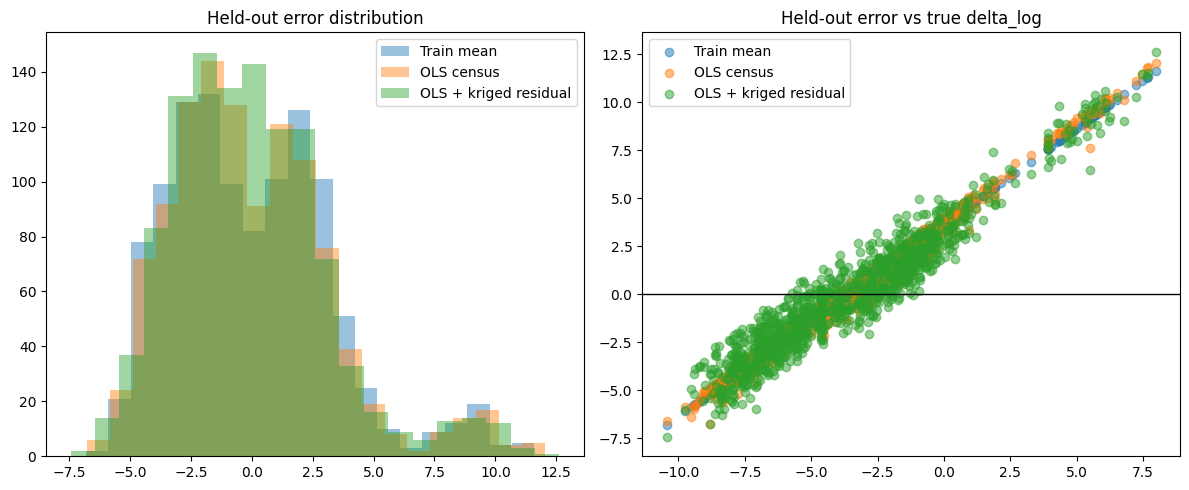

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(null_errors, bins=20, alpha=0.45, label="Train mean")
plt.hist(ols_errors, bins=20, alpha=0.45, label="OLS census")
plt.hist(ols_krig_errors, bins=20, alpha=0.45, label="OLS + kriged residual")
plt.legend()
plt.title("Held-out error distribution")

plt.subplot(1, 2, 2)
plt.scatter(test_values, null_errors, alpha=0.5, label="Train mean")
plt.scatter(test_values, ols_errors, alpha=0.5, label="OLS census")
plt.scatter(test_values, ols_krig_errors, alpha=0.5, label="OLS + kriged residual")
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.title("Held-out error vs true delta_log")

plt.tight_layout()

In [ ]:
# residual-only comparison, matching the empirical variogram target
resid_null_pred = train["delta_log_resid"].mean()
resid_null_errors = test_residuals - resid_null_pred

pd.DataFrame({
    "model": ["Residual train mean", "Kriged residual"],
    "MAE": [
        np.mean(np.abs(resid_null_errors)),
        np.mean(np.abs(resid_krig_errors)),
    ],
    "RMSE": [
        np.sqrt(np.mean(resid_null_errors ** 2)),
        np.sqrt(np.mean(resid_krig_errors ** 2)),
    ],
})

,model,MAE,RMSE
0,Residual train mean,2.568898,3.273203
1,Kriged residual,2.462522,3.190631


# Bayesian model

In [28]:
RUN_BAYESIAN_SPATIAL = True
BAYESIAN_SAMPLE_N = 500  # full train set; set to e.g. 1000 for a faster/lighter fit
BAYESIAN_TRACE_PATH = pathlib.Path("trace_delta_census.pkl")

In [29]:
def prepare_spatial_delta_data(
    df,
    covariates=("population", "median_income"),
    sample_n=None,
    random_state=305,
    covariate_means=None,
    covariate_sds=None,
):
    cols = ["delta_log", "lat", "lng", *covariates]
    sample = df.dropna(subset=cols).copy().reset_index(drop=True)

    if sample_n is not None and sample_n < len(sample):
        sample = sample.sample(n=sample_n, random_state=random_state).reset_index(drop=True)

    gdf = gpd.GeoDataFrame(
        sample,
        geometry=gpd.points_from_xy(sample["lng"], sample["lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:5070")
    coords_km = np.column_stack([gdf.geometry.x, gdf.geometry.y]) / 1000

    X_raw = sample[list(covariates)].astype(float)
    if covariate_means is None:
        covariate_means = X_raw.mean()
    if covariate_sds is None:
        covariate_sds = X_raw.std(ddof=0).replace(0, 1)

    X_scaled = (X_raw - covariate_means) / covariate_sds
    X = np.column_stack([np.ones(len(sample)), X_scaled.values])
    y = sample["delta_log"].values.astype(float)

    return {
        "sample": sample,
        "coords_km": coords_km,
        "X": X,
        "y": y,
        "covariates": list(covariates),
        "covariate_means": covariate_means,
        "covariate_sds": covariate_sds,
    }

In [30]:
def fit_bayesian_spatial_delta_model(
    df,
    covariates=("population", "median_income"),
    sample_n=None,
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    target_accept=0.9,
    beta_sigma=10.0,
    nugget_ratio_bounds=(1.0, 100.0),
    inv_phi_bounds=(1.0, 2000.0),  # kilometers, after EPSG:5070 projection
    n_prior_samples=100,
    jitter=1e-6,
    **pm_kwargs,
):
    data = prepare_spatial_delta_data(
        df,
        covariates=covariates,
        sample_n=sample_n,
    )

    X = data["X"]
    y = data["y"]
    coords_km = data["coords_km"]
    D = cdist(coords_km, coords_km)
    n = len(y)

    with pm.Model() as model:
        log_sigma2 = pm.Normal("log_sigma2", mu=0, sigma=10)
        sigma2 = pm.Deterministic("sigma2", pm.math.exp(log_sigma2))
        nugget_ratio = pm.Uniform(
            "nugget_ratio",
            lower=nugget_ratio_bounds[0],
            upper=nugget_ratio_bounds[1],
        )
        inv_phi = pm.Uniform(
            "inv_phi",
            lower=inv_phi_bounds[0],
            upper=inv_phi_bounds[1],
        )
        phi = pm.Deterministic("phi", 1.0 / inv_phi)
        beta = pm.Normal("beta", mu=0, sigma=beta_sigma, shape=X.shape[1])

        H = pm.math.exp(-(phi ** 2) * D ** 2)
        Sigma = sigma2 * H + nugget_ratio * sigma2 * pt.eye(n) + jitter * pt.eye(n)
        mu = pm.math.dot(X, beta)
        pm.MvNormal("y_obs", mu=mu, cov=Sigma, observed=y)

        prior = pm.sample_prior_predictive(samples=n_prior_samples)
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            idata_kwargs={"log_likelihood": True},
            return_inferencedata=True,
            **pm_kwargs,
        )
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    trace.extend(prior)
    return trace, data


In [31]:
trace_delta_census = None
bayes_train_data = None

if RUN_BAYESIAN_SPATIAL:
    trace_delta_census, bayes_train_data = fit_bayesian_spatial_delta_model(
        train,
        covariates=census_covariates,
        sample_n=BAYESIAN_SAMPLE_N,
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        target_accept=0.9,
        nugget_ratio_bounds=(1.0, 100.0),
        inv_phi_bounds=(1.0, 2000.0),
        beta_sigma=10.0,
        n_prior_samples=100,
    )
    with open(BAYESIAN_TRACE_PATH, "wb") as f:
        pickle.dump({"trace": trace_delta_census, "data": bayes_train_data}, f)
elif BAYESIAN_TRACE_PATH.exists():
    with open(BAYESIAN_TRACE_PATH, "rb") as f:
        saved = pickle.load(f)
    trace_delta_census = saved["trace"]
    bayes_train_data = saved["data"]


Sampling: [beta, inv_phi, log_sigma2, nugget_ratio, y_obs]
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log_sigma2, nugget_ratio, inv_phi, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4453 seconds.
Sampling: [y_obs]


Output()

Divergences:          0
Mean acceptance rate: 0.918
Mean step size:       0.0944
Max tree depth:       8


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-3.3719,0.4322,-4.1396,-2.6464,0.0146,0.0337,1633.0367,1016.3672,1.0017
beta[1],0.2813,0.1553,-0.0026,0.5732,0.0031,0.0027,2529.2246,2405.9573,1.0010
beta[2],0.1487,0.1618,-0.1522,0.4543,0.0036,0.0027,2045.0509,2563.0054,1.0005
sigma2,1.0024,0.7541,0.1166,2.1361,0.0266,0.0836,858.5148,797.6053,1.0024
nugget_ratio,15.9173,13.2948,1.1271,39.1259,0.5423,0.8797,845.0027,756.9594,1.0024
inv_phi,393.4755,372.0395,82.5399,1272.1828,17.5255,21.3142,770.9780,753.3046,1.0010


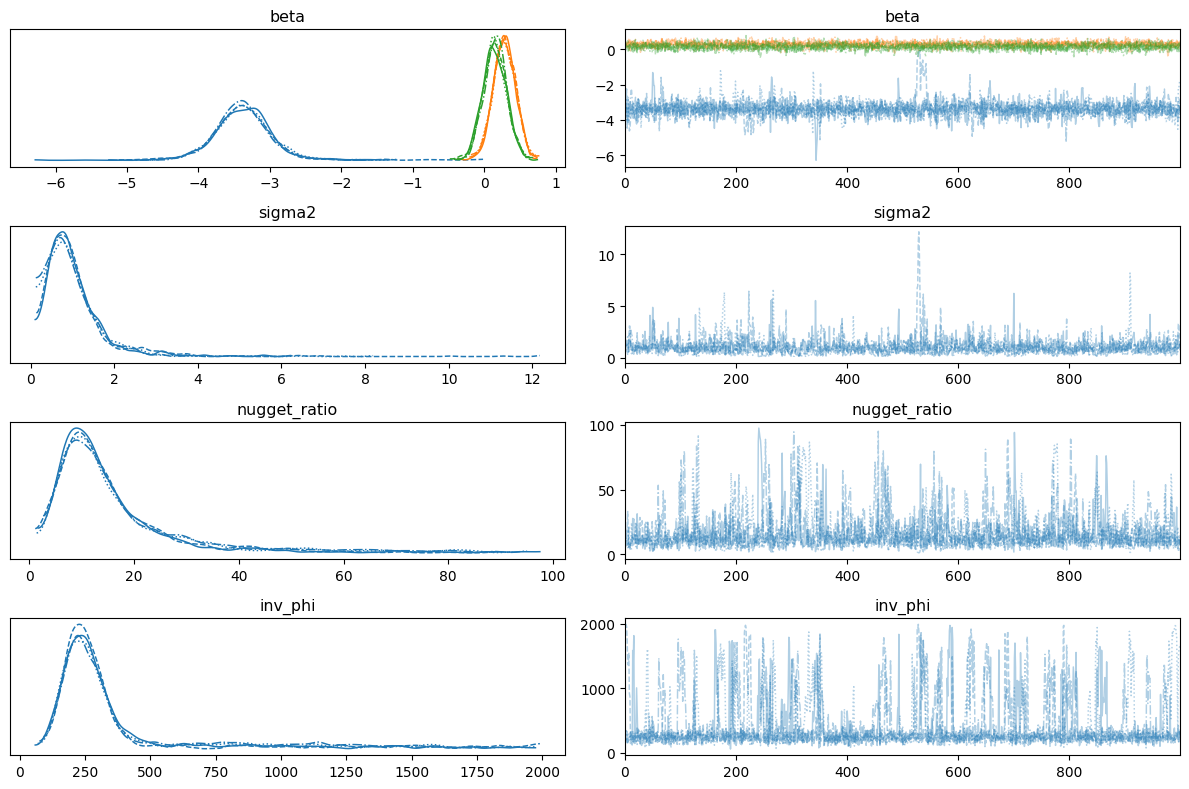

In [32]:
if trace_delta_census is not None:
    diag_vars = ["beta", "sigma2", "nugget_ratio", "inv_phi"]

    n_div = int(trace_delta_census.sample_stats["diverging"].values.sum())
    acc = float(trace_delta_census.sample_stats["acceptance_rate"].values.mean())
    step = float(trace_delta_census.sample_stats["step_size"].values.mean())
    max_td = int(trace_delta_census.sample_stats["tree_depth"].values.max())

    print(f"Divergences:          {n_div}")
    print(f"Mean acceptance rate: {acc:.3f}")
    print(f"Mean step size:       {step:.4f}")
    print(f"Max tree depth:       {max_td}")
    display(az.summary(trace_delta_census, var_names=diag_vars, round_to=4))

    az.plot_trace(trace_delta_census, var_names=diag_vars, compact=True)
    plt.tight_layout()

In [33]:
def bayesian_spatial_delta_predict(trace, train_data, test_df, n_posterior_samples=200):
    test_data = prepare_spatial_delta_data(
        test_df,
        covariates=train_data["covariates"],
        covariate_means=train_data["covariate_means"],
        covariate_sds=train_data["covariate_sds"],
    )

    X_train = train_data["X"]
    X_test = test_data["X"]
    y_train = train_data["y"]
    y_test = test_data["y"]
    coords_train = train_data["coords_km"]
    coords_test = test_data["coords_km"]

    D_tt = cdist(coords_train, coords_train)
    D_st = cdist(coords_test, coords_train)

    post = trace.posterior
    beta = post["beta"].values.reshape(-1, post["beta"].shape[-1])
    sigma2 = post["sigma2"].values.reshape(-1)
    phi = post["phi"].values.reshape(-1)
    nugget = post["nugget_ratio"].values.reshape(-1)

    idx = np.linspace(0, len(sigma2) - 1, min(n_posterior_samples, len(sigma2)), dtype=int)
    preds = np.zeros((len(idx), len(test_data["sample"])))

    for k, s in enumerate(idx):
        H_tt = np.exp(-(phi[s] ** 2) * D_tt ** 2)
        H_st = np.exp(-(phi[s] ** 2) * D_st ** 2)
        Sigma_tt = sigma2[s] * H_tt + nugget[s] * sigma2[s] * np.eye(len(y_train))
        Sigma_st = sigma2[s] * H_st
        mu_train = X_train @ beta[s]
        mu_test = X_test @ beta[s]
        preds[k] = mu_test + Sigma_st @ np.linalg.solve(Sigma_tt, y_train - mu_train)

    return preds.mean(axis=0), y_test, test_data

In [34]:
if trace_delta_census is not None and bayes_train_data is not None:
    bayes_pred, bayes_y_test, bayes_test_data = bayesian_spatial_delta_predict(
        trace_delta_census,
        bayes_train_data,
        test,
        n_posterior_samples=200,
    )

    bayes_errors = bayes_y_test - bayes_pred
    ols_test_errors = bayes_y_test - bayes_test_data["sample"]["delta_log_ols_fitted"].values
    null_test_errors = bayes_y_test - bayes_train_data["y"].mean()

    bayes_comparison = pd.DataFrame({
        "model": ["Train mean", "OLS census", "Bayesian spatial census"],
        "MAE": [
            np.mean(np.abs(null_test_errors)),
            np.mean(np.abs(ols_test_errors)),
            np.mean(np.abs(bayes_errors)),
        ],
        "RMSE": [
            np.sqrt(np.mean(null_test_errors ** 2)),
            np.sqrt(np.mean(ols_test_errors ** 2)),
            np.sqrt(np.mean(bayes_errors ** 2)),
        ],
    })
    display(bayes_comparison)

,model,MAE,RMSE
0,Train mean,2.696587,3.304215
1,OLS census,2.568159,3.273140
2,Bayesian spatial census,2.547497,3.244915


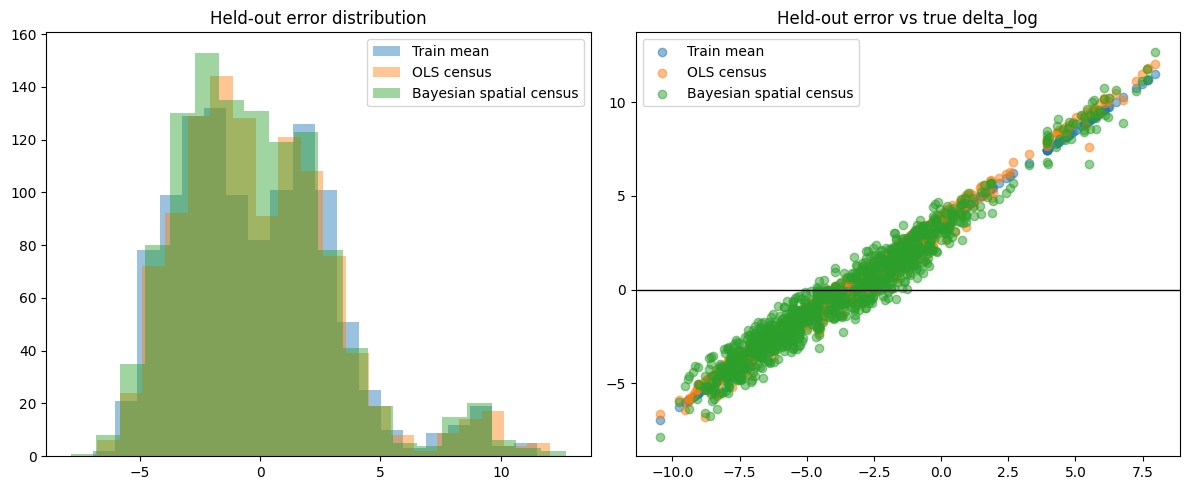

In [35]:
if trace_delta_census is not None and bayes_train_data is not None:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(null_test_errors, bins=20, alpha=0.45, label="Train mean")
    plt.hist(ols_test_errors, bins=20, alpha=0.45, label="OLS census")
    plt.hist(bayes_errors, bins=20, alpha=0.45, label="Bayesian spatial census")
    plt.legend()
    plt.title("Held-out error distribution")

    plt.subplot(1, 2, 2)
    plt.scatter(bayes_y_test, null_test_errors, alpha=0.5, label="Train mean")
    plt.scatter(bayes_y_test, ols_test_errors, alpha=0.5, label="OLS census")
    plt.scatter(bayes_y_test, bayes_errors, alpha=0.5, label="Bayesian spatial census")
    plt.axhline(0, color="black", linewidth=1)
    plt.legend()
    plt.title("Held-out error vs true delta_log")

    plt.tight_layout()